In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
import os

import psycopg
import pandas as pd
import mlflow
from catboost import CatBoostClassifier
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

TABLE_NAME = "clean_users_churn"
TRACKING_SERVER_HOST = "127.0.0.1"
TRACKING_SERVER_PORT = 5000

EXPERIMENT_NAME = "churn_simonreise"
RUN_NAME = "feature_selection"
REGISTRY_MODEL_NAME = "churn_model_simonreise_catboost_basic"
FS_ASSETS = "fs_assets" 

In [3]:
os.environ["MLFLOW_S3_ENDPOINT_URL"] = "https://storage.yandexcloud.net"
os.environ["AWS_ACCESS_KEY_ID"] = os.getenv("AWS_ACCESS_KEY_ID")
os.environ["AWS_SECRET_ACCESS_KEY"] = os.getenv("AWS_SECRET_ACCESS_KEY")

mlflow.set_tracking_uri(f"http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}")
mlflow.set_registry_uri(f"http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}")

In [15]:
import psycopg

connection = {"sslmode": "require", "target_session_attrs": "read-write"}
postgres_credentials = {
    "host": os.getenv("DB_DESTINATION_HOST"),
    "port": os.getenv("DB_DESTINATION_PORT"),
    "dbname": os.getenv("DB_DESTINATION_NAME"),
    "user": os.getenv("DB_DESTINATION_USER"),
    "password": os.getenv("DB_DESTINATION_PASSWORD"),
}

connection.update(postgres_credentials)

with psycopg.connect(**connection) as conn:

    with conn.cursor() as cur:
        cur.execute(f"SELECT * FROM {TABLE_NAME}")
        data = cur.fetchall()
        columns = [col[0] for col in cur.description]

df = pd.DataFrame(data, columns=columns)

df = df.drop(columns=["id", "end_date", "customer_id"])

df.head(2) 

,begin_date,type,paperless_billing,payment_method,monthly_charges,total_charges,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,gender,senior_citizen,partner,dependents,multiple_lines,target
0,2019-01-01,Month-to-month,Yes,Mailed check,49.95,587.45,DSL,Yes,No,No,No,No,No,Male,0,Yes,Yes,No,0
1,2016-09-01,Two year,No,Mailed check,20.65,835.15,Fiber optic,No,No,No,No,No,No,Female,0,No,No,No,0


In [17]:
from sklearn.model_selection import train_test_split

split_column = "begin_date"
test_size = 0.2

df = df.sort_values(by=[split_column])

X_train, X_test, y_train, y_test = train_test_split(
    df.drop(columns=["target"]),
    df["target"],
    test_size=test_size,
    shuffle=False,
) 

In [18]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

cat_features = X_train.select_dtypes(include='object')
potential_binary_features = cat_features.nunique() == 2

binary_cat_features = cat_features[potential_binary_features[potential_binary_features].index]
other_cat_features = cat_features[potential_binary_features[~potential_binary_features].index]
num_features = X_train.select_dtypes(['float'])

preprocessor = ColumnTransformer(
    [
        ('binary', OneHotEncoder(drop='if_binary'), binary_cat_features.columns.tolist()),
        ('cat', OneHotEncoder(), other_cat_features.columns.tolist()),
        ('num', StandardScaler(), num_features.columns.tolist())
    ],
    remainder='drop',
    verbose_feature_names_out=False
)
X_train = preprocessor.fit_transform(X_train, y_train)
X_test = preprocessor.transform(X_test)

In [19]:
estimator = RandomForestClassifier(n_estimators=300)

sfs = SFS(
    estimator,
    k_features=10,       
    forward=True,      
    floating=False,     
    scoring='roc_auc',
    cv=4,            
    n_jobs=-1,
)
sbs = SFS(
    estimator,
    k_features=10,       
    forward=False,      
    floating=False,     
    scoring='roc_auc',
    cv=4,            
    n_jobs=-1,
)

sfs = sfs.fit(X_train, y_train) # запустите отбор признаков
sbs = sbs.fit(X_train, y_train)

top_sfs = sfs.k_feature_idx_
top_sbs = sbs.k_feature_idx_

print('\nSequential Forward Selection (k=10)')
print('CV Score:')
print(sfs.k_score_)

print('\nSequential Backward Selection')
print('CV Score:')
print(sbs.k_score_)


Sequential Forward Selection (k=10)
CV Score:
0.8166760883881772

Sequential Backward Selection
CV Score:
0.7814973235845707


In [20]:
sfs_df = pd.DataFrame.from_dict(sfs.get_metric_dict()).T
sbs_df = pd.DataFrame.from_dict(sbs.get_metric_dict()).T 

In [21]:
os.makedirs(FS_ASSETS, exist_ok=True)

sfs_df.to_csv(f"{FS_ASSETS}/sfs.csv")
sbs_df.to_csv(f"{FS_ASSETS}/sbs.csv") 

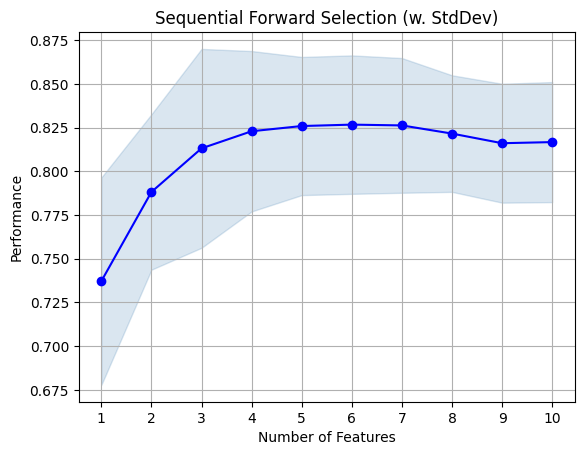

<Figure size 640x480 with 0 Axes>

In [23]:
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs

fig = plot_sfs(sfs.get_metric_dict(), kind='std_dev')

plt.title('Sequential Forward Selection (w. StdDev)')
plt.grid()
plt.show()

plt.savefig(f"{FS_ASSETS}/sfs.png") 

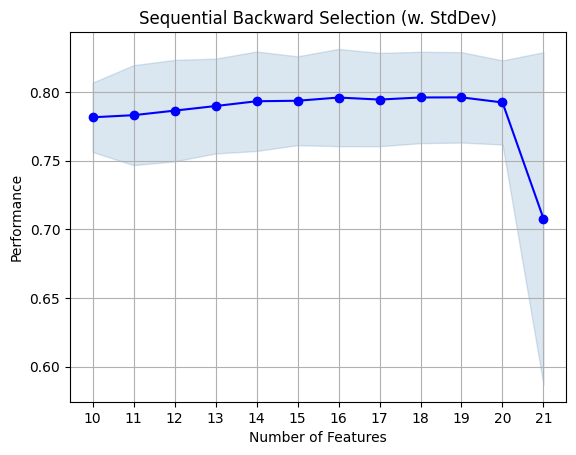

<Figure size 640x480 with 0 Axes>

In [25]:
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs

fig = plot_sfs(sbs.get_metric_dict(), kind='std_dev')

plt.title('Sequential Backward Selection (w. StdDev)')
plt.grid()
plt.show()

plt.savefig(f"{FS_ASSETS}/sbs.png") 

In [28]:
print(top_sbs)
print(sbs.k_feature_names_)

(0, 2, 4, 5, 8, 9, 12, 14, 17, 19)
('0', '2', '4', '5', '8', '9', '12', '14', '17', '19')


In [31]:
print(top_sfs)
print(sfs.k_feature_names_)

(0, 1, 9, 12, 13, 14, 15, 16, 17, 18)
('0', '1', '9', '12', '13', '14', '15', '16', '17', '18')


In [33]:
interc_features = list(set(top_sbs) & set(top_sfs))
union_features = list(set(top_sbs) | set(top_sfs))

In [34]:
experiment_id = mlflow.get_experiment_by_name(EXPERIMENT_NAME).experiment_id

with mlflow.start_run(run_name=f"{RUN_NAME}_intersection_and_union", experiment_id=experiment_id) as run:
    run_id = run.info.run_id
   
    mlflow.log_artifacts(FS_ASSETS)
    print(run_id)

4376030cd9d44e0fac34ab10e4fdf15f


In [40]:
from catboost import CatBoostClassifier

X_train_features = X_train[:, interc_features]
X_test_features = X_test[:, interc_features]

model = CatBoostClassifier(auto_class_weights='Balanced')
model.fit(X_train[:, interc_features], y_train)

Learning rate set to 0.021523
0:	learn: 0.6866006	total: 54.3ms	remaining: 54.2s
1:	learn: 0.6805965	total: 55.7ms	remaining: 27.8s
2:	learn: 0.6731066	total: 57.3ms	remaining: 19s
3:	learn: 0.6665222	total: 58.6ms	remaining: 14.6s
4:	learn: 0.6603010	total: 59.9ms	remaining: 11.9s
5:	learn: 0.6545098	total: 61.2ms	remaining: 10.1s
6:	learn: 0.6488588	total: 62.6ms	remaining: 8.88s
7:	learn: 0.6435627	total: 63.9ms	remaining: 7.93s
8:	learn: 0.6384409	total: 65.2ms	remaining: 7.17s
9:	learn: 0.6344003	total: 66.3ms	remaining: 6.57s
10:	learn: 0.6298383	total: 67.6ms	remaining: 6.08s
11:	learn: 0.6253620	total: 68.9ms	remaining: 5.67s
12:	learn: 0.6206403	total: 70.7ms	remaining: 5.37s
13:	learn: 0.6166007	total: 72.4ms	remaining: 5.1s
14:	learn: 0.6124070	total: 74ms	remaining: 4.86s
15:	learn: 0.6087565	total: 75.4ms	remaining: 4.63s
16:	learn: 0.6052949	total: 76.8ms	remaining: 4.44s
17:	learn: 0.6020588	total: 78.2ms	remaining: 4.26s
18:	learn: 0.5993729	total: 79.4ms	remaining: 4.1

In [41]:
prediction = model.predict(X_test_features)
probas = model.predict_proba(X_test_features)

In [42]:
from sklearn.metrics import confusion_matrix, roc_auc_score, precision_score, recall_score, f1_score, log_loss
# импортируйте необходимые вам модули

# заведите словарь со всеми метриками
metrics = {}

# посчитайте метрики из модуля sklearn.metrics
# err_1 — ошибка первого рода
# err_2 — ошибка второго рода
_, err1, _, err2 = confusion_matrix(y_test, prediction, normalize="all").ravel()
auc = roc_auc_score(y_test, probas[:, 1])
precision = precision_score(y_test, prediction)
recall = recall_score(y_test, prediction)
f1 = f1_score(y_test, prediction)
logloss = log_loss(y_test, prediction)

# запишите значения метрик в словарь
metrics["err1"] = err1
metrics["err2"] = err2
metrics["auc"] = auc
metrics["precision"] = precision
metrics["recall"] = recall
metrics["f1"] = f1
metrics["logloss"] = logloss

In [43]:
pip_requirements = "./requirements.txt"
signature = mlflow.models.infer_signature(X_test_features, prediction)
input_example = X_test_features[:10]
metadata = {"model_type": "monthly"}

In [44]:
experiment_id = mlflow.get_experiment_by_name(EXPERIMENT_NAME).experiment_id

with mlflow.start_run(run_name=f"{RUN_NAME}_intersection_model", experiment_id=experiment_id) as run:
    run_id = run.info.run_id
    # ваш код здесь
    model_info = mlflow.catboost.log_model(
        cb_model=model,
        artifact_path="models",
        pip_requirements=pip_requirements,
        signature=signature,
        input_example=input_example,
        metadata=metadata,
        registered_model_name=REGISTRY_MODEL_NAME,
        await_registration_for=60,
    )
    mlflow.log_metrics(metrics)

Registered model 'churn_model_simonreise_catboost_basic' already exists. Creating a new version of this model...
2026/03/08 14:17:18 INFO mlflow.tracking._model_registry.client: Waiting up to 60 seconds for model version to finish creation. Model name: churn_model_simonreise_catboost_basic, version 6
Created version '6' of model 'churn_model_simonreise_catboost_basic'.


In [45]:
from catboost import CatBoostClassifier

X_train_features = X_train[:, union_features]
X_test_features = X_test[:, union_features]

model = CatBoostClassifier(auto_class_weights='Balanced')
model.fit(X_train[:, interc_features], y_train)

Learning rate set to 0.021523
0:	learn: 0.6866006	total: 1.71ms	remaining: 1.7s
1:	learn: 0.6805965	total: 3.05ms	remaining: 1.52s
2:	learn: 0.6731066	total: 4.73ms	remaining: 1.57s
3:	learn: 0.6665222	total: 6.15ms	remaining: 1.53s
4:	learn: 0.6603010	total: 7.58ms	remaining: 1.51s
5:	learn: 0.6545098	total: 8.95ms	remaining: 1.48s
6:	learn: 0.6488588	total: 10.3ms	remaining: 1.46s
7:	learn: 0.6435627	total: 11.7ms	remaining: 1.45s
8:	learn: 0.6384409	total: 12.9ms	remaining: 1.42s
9:	learn: 0.6344003	total: 14.1ms	remaining: 1.39s
10:	learn: 0.6298383	total: 15.2ms	remaining: 1.37s
11:	learn: 0.6253620	total: 16.4ms	remaining: 1.35s
12:	learn: 0.6206403	total: 18ms	remaining: 1.36s
13:	learn: 0.6166007	total: 19.3ms	remaining: 1.36s
14:	learn: 0.6124070	total: 20.7ms	remaining: 1.36s
15:	learn: 0.6087565	total: 22ms	remaining: 1.35s
16:	learn: 0.6052949	total: 23.3ms	remaining: 1.35s
17:	learn: 0.6020588	total: 24.6ms	remaining: 1.34s
18:	learn: 0.5993729	total: 25.9ms	remaining: 1.3

In [46]:
prediction = model.predict(X_test_features)
probas = model.predict_proba(X_test_features)

In [47]:
from sklearn.metrics import confusion_matrix, roc_auc_score, precision_score, recall_score, f1_score, log_loss
# импортируйте необходимые вам модули

# заведите словарь со всеми метриками
metrics = {}

# посчитайте метрики из модуля sklearn.metrics
# err_1 — ошибка первого рода
# err_2 — ошибка второго рода
_, err1, _, err2 = confusion_matrix(y_test, prediction, normalize="all").ravel()
auc = roc_auc_score(y_test, probas[:, 1])
precision = precision_score(y_test, prediction)
recall = recall_score(y_test, prediction)
f1 = f1_score(y_test, prediction)
logloss = log_loss(y_test, prediction)

# запишите значения метрик в словарь
metrics["err1"] = err1
metrics["err2"] = err2
metrics["auc"] = auc
metrics["precision"] = precision
metrics["recall"] = recall
metrics["f1"] = f1
metrics["logloss"] = logloss

In [48]:
pip_requirements = "./requirements.txt"
signature = mlflow.models.infer_signature(X_test_features, prediction)
input_example = X_test_features[:10]
metadata = {"model_type": "monthly"}

In [49]:
experiment_id = mlflow.get_experiment_by_name(EXPERIMENT_NAME).experiment_id

with mlflow.start_run(run_name=f"{RUN_NAME}_union_model", experiment_id=experiment_id) as run:
    run_id = run.info.run_id
    # ваш код здесь
    model_info = mlflow.catboost.log_model(
        cb_model=model,
        artifact_path="models",
        pip_requirements=pip_requirements,
        signature=signature,
        input_example=input_example,
        metadata=metadata,
        registered_model_name=REGISTRY_MODEL_NAME,
        await_registration_for=60,
    )
    mlflow.log_metrics(metrics)

Registered model 'churn_model_simonreise_catboost_basic' already exists. Creating a new version of this model...
2026/03/08 14:19:50 INFO mlflow.tracking._model_registry.client: Waiting up to 60 seconds for model version to finish creation. Model name: churn_model_simonreise_catboost_basic, version 7
Created version '7' of model 'churn_model_simonreise_catboost_basic'.
